# Simple Scheduling Algorithm using QAOA



N tasks    \
M workers  \
M <= N     

Assign tasks to workers    \
Each task assigned only to one worker

input  - Weight matrix, W \
output - optimized scheuling of tasks to workers resulting a least cost \
                      \
W(i, j) indicate the cost of jth task assigned to ith worker



### QAOA procedure for Simple Scheduling

1. Weight matrix to QUBO Cost

2. QUBO Cost to Hamiltonian

3. QAOA Circuit
    * QAOA Ansatz
    * Transpile to Aer Simulator circuit

4. Optimization
    * Estimator for evaluating Energy or Cost
    * Classical parameter optimization through minimize function

5. Results
    * Generate Sampler output of the circuit assigned with best parameters
    * Optimal Scheduling
    * Visualization



In [33]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\kcrav\miniconda3\envs\myenv\python.exe
Python version: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


In [34]:
#!jupyter kernelspec list

In [35]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.quantum_info import Statevector

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator, EstimatorOptions
from qiskit_ibm_runtime import SamplerV2 as Sampler

from scipy.optimize import minimize

## Weight matrix to Classical QUBO Cost




In [36]:
N = 3
M = 2
K = int(np.ceil(np.log2(N)))
p_reps = 1

def inititialize_parameters(p_reps):

    init_param_values = [np.pi/np.random.randint(3,20) for _ in range(2*p_reps)]

    '''
    if p_reps == 8:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 6, np.pi/4.8, np.pi / 5]
    if p_reps == 7:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 6, np.pi/4.8, np.pi / 5, np.pi/4.2, np.pi/4.1, np.pi/3.7]
    if p_reps == 6:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 6, np.pi/4.8, np.pi / 5, np.pi/4.8, np.pi / 5]
    if p_reps == 5:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 6, np.pi/4.8, np.pi / 5, np.pi/4.2]
    if p_reps == 4:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 6, np.pi/4.8, np.pi / 5]
    elif p_reps == 3:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 5]
    elif p_reps == 2:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 5, np.pi/4.5]
    elif p_reps == 1:
        init_param_values = [np.pi / 3, np.pi / 6]
    '''

    return init_param_values

init_param_values = inititialize_parameters(p_reps)

assert N > 0 and M > 0, "N and M must be positive integers."
#assert N >= M, "N must be greater than or equal to M for a valid scheduling problem."

def generate_weight_matrix(M, N):
    w = np.random.randint(1, 1000, size=(M, N))
    return w

w = generate_weight_matrix(M, N)
print('w:', w)

w_col = w.reshape(-1, 1)
print(w_col)


w: [[479 490 779]
 [691 423 547]]
[[479]
 [490]
 [779]
 [691]
 [423]
 [547]]


### brute_force_min_max_wx

In [37]:
def brute_force_min_max_wx(w, M, N):
    Time_brute_force_min_max_wx = 100000000
    x_brute_force_min_max_wx = None
    for i in range(2**(M*N)):
        x = np.array(list(np.binary_repr(i, width=M*N)), dtype=int)
        
        reshaped_x = np.array(x).reshape(M,N)        

        if np.sum(reshaped_x) != N:
            continue        

        bool_skip_maxTime = 0
        for l in range(N):
            if np.sum(reshaped_x[:,l])!=1:
                bool_skip_maxTime = 1
                break

        if bool_skip_maxTime:
            continue

        alloted_times = reshaped_x * w
        max_time = 0
        for j in range(M):
            max_time = max(max_time, np.sum(alloted_times[j,:]))
        if Time_brute_force_min_max_wx > max_time:
            Time_brute_force_min_max_wx = max_time
            x_brute_force_min_max_wx = reshaped_x
        #print(max_time)

    return Time_brute_force_min_max_wx, x_brute_force_min_max_wx

if M*N <= 20:
    Time_brute_force_min_max_wx, x_brute_force_min_max_wx = brute_force_min_max_wx(w, M, N)
    
    print('w \n', w)    
    print('x_brute_force_min_max_wx \n', x_brute_force_min_max_wx)
    print('Time_brute_force_min_max_wx: ', Time_brute_force_min_max_wx)


w 
 [[479 490 779]
 [691 423 547]]
x_brute_force_min_max_wx 
 [[1 1 0]
 [0 0 1]]
Time_brute_force_min_max_wx:  969


### QUBO_Q_C

In [38]:
def QUBO_Q_C(w, a,b,c):

    Q = np.zeros((M * N + M*K + K, M * N + M*K + K))  # initialize Q as a lower triangular matrix of ones


    A_ = a
    B_ = b
    C_ = c



    const_0_1 = 0

    w = w/np.sum(w.reshape(1,-1))

    for i in range(M):
        for j in range(N):
            for l in range(j):
                Q[i * N + j, i * N + l] = (1+const_0_1)*A_*w[i,j]*w[i,l]
                Q[i * N + l, i * N + j] = (1-const_0_1)*A_*w[i,l]*w[i,j]
    row_offset = M*N
    col_offset = M*N
    for i in range(M):
        for j in range(K):
            for l in range(j):
                Q[row_offset + i * K + j, col_offset + i * K + l] = (1+const_0_1)*A_*2**(j+l)
                Q[row_offset + i * K + l, col_offset + i * K + j] = (1-const_0_1)*A_*2**(j+l)
    row_offset = M*N+M*K
    col_offset = M*N+M*K
    for i in range(1):
        for j in range(K):
            for l in range(j):
                Q[row_offset + i * K + j, col_offset + i * K + l] = (1+const_0_1)*A_*2**(j+l)
                Q[row_offset + i * K + l, col_offset + i * K + j] = (1-const_0_1)*A_*2**(j+l)
    row_offset = M*N
    col_offset = 0
    for i in range(M):
        for j in range(K):
            for l in range(N):
                Q[row_offset + i * K + j, col_offset + i * N + l] = (1+const_0_1)*A_*(2**j)*w[i,l]
                Q[col_offset + i * N + l, row_offset + i * K + j] = (1-const_0_1)*A_*(2**j)*w[i,l]
    row_offset = M*N+M*K
    col_offset = 0
    for i in range(M):
        for j in range(K):
            for l in range(N):
                Q[row_offset + j, col_offset + i * N + l] = -(1+const_0_1)*A_*(2**j)*w[i,l]
                Q[col_offset + i * N + l, row_offset + j] = -(1-const_0_1)*A_*(2**j)*w[i,l]
    row_offset = M*N+M*K
    col_offset = M*N
    for i in range(M):
        for j in range(K):
            for l in range(K):
                Q[row_offset + j, col_offset + i * K + l] = -(1+const_0_1)*A_*2**(j+l)
                Q[col_offset + i * K + l, row_offset + j] = -(1-const_0_1)*A_*2**(j+l)

    for j in range(N):
        for i in range(M):
            for n in range(i):
                Q[i * N + j, n * N + j] += (1+const_0_1)*B_
                Q[n * N + j, i * N + j] += (1-const_0_1)*B_

    M1 = np.zeros(M*N)
    M2 = np.zeros(M*K)
    M3 = np.zeros(K)
    for i in range(M):
        for j in range(N):
            M1[i*N + j] = A_*w[i,j]*w[i,j] + B_ - 2*B_
    for i in range(M):
        for j in range(K):
            M2[i*K + j] = A_*(2**(2*j))   #  i replaced with j
    for i in range(K):
            M3[i] = A_*2**(2*i) + C_*(2**i)

    C = np.concatenate((M1, M2, M3), axis=0)

    #print(M*N, M*K, K, len(C), M*N+M*K+K)

    #C = w_col/(np.sum(w_col)) - 1/(N)*np.ones((M * N, 1))
    #C = w_col*(.5/(2*L)) - .5*np.ones((M * N, 1))
    #C = .1*w_col - L*np.ones((M * N, 1))

    #print(np.diag(Q))
    #print(np.diag(np.diag(Q)))
    #Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero


    #print('Q:', Q)
    #print('C:', C)

    return Q, C


### brute_force_QUBO_classical

In [39]:
def qubo_cost_function(x, Q, C):
    return 0.5 * x.T @ Q @ x + C.T @ x

Q, C = QUBO_Q_C(w, 10,10,1)


# brute-force search for CLASSICAL QUBO
def brute_force_QUBO_classical(Q, C, w, M, N, K):
    min_cost = 100000000
    x_brute_force_QUBO_classical = None
    for i in range(2**(M*N+M*K+K)):
        x = np.array(list(np.binary_repr(i, width=M*N+M*K+K)), dtype=int)
        cost = qubo_cost_function(x, Q, C)
        #print(x[:M*N].reshape(M,N), x,cost)
        if cost < min_cost:
            min_cost = cost
            x_brute_force_QUBO_classical = x
            #print(f"New minimum cost: {min_cost}", "x:", x[:M*N].reshape(M,N))

    reshaped_x = x_brute_force_QUBO_classical[:M*N].reshape(M,N)
    alloted_times = reshaped_x * w
    max_time = 0
    for j in range(M):
        max_time = max(max_time, np.sum(alloted_times[j,:]))
    Time_brute_force_QUBO_classical = max_time
    x_brute_force_QUBO_classical = reshaped_x

    return Time_brute_force_QUBO_classical, x_brute_force_QUBO_classical

if M*N+M*K+K <= 0:# 20:

    Time_brute_force_QUBO_classical, x_brute_force_QUBO_classical = brute_force_QUBO_classical(Q, C, w, M, N, K)

    print('x_brute_force_QUBO_classical \n', x_brute_force_QUBO_classical)
    print('Time_brute_force_QUBO_classical', Time_brute_force_QUBO_classical)
    print('w', w)



## Classical QUBO to Hamiltonian




### function definition

In [40]:
def classical_qubo_to_hamiltonian(Q, C):
    n = len(C)
    pauli_list = []
    
    for i in range(n):
        if C[i] != 0 or np.sum(Q[i,:]) != 0:
            pauli_list.append(('Z', [i], -np.float64(np.sum(Q[i,:])/4 + np.sum(Q[:,i])/4 + C[i]/2)))
            #pauli_list.append(('Z', [i], -np.float64(np.sum(Q[i,:])/2 + C[i][0]/2)))
            pass
    
    for i in range(n):
        for j in range(i):
            if Q[i, j] != 0:
                pauli_list.append(('ZZ', [i, j], np.float64(Q[i, j]/4)))
                pauli_list.append(('ZZ', [j, i], np.float64(Q[j, i]/4)))
                pass
    
    return pauli_list

In [41]:
pauli_list = classical_qubo_to_hamiltonian(Q/2, C)
no_of_qubits = M*N + M*K + K
Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=no_of_qubits)
Cost_hamiltonian

SparsePauliOp(['IIIIIIIIIIIZ', 'IIIIIIIIIIZI', 'IIIIIIIIIZII', 'IIIIIIIIZIII', 'IIIIIIIZIIII', 'IIIIIIZIIIII', 'IIIIIZIIIIII', 'IIIIZIIIIIII', 'IIIZIIIIIIII', 'IIZIIIIIIIII', 'IZIIIIIIIIII', 'ZIIIIIIIIIII', 'IIIIIIIIIIZZ', 'IIIIIIIIIIZZ', 'IIIIIIIIIZIZ', 'IIIIIIIIIZIZ', 'IIIIIIIIIZZI', 'IIIIIIIIIZZI', 'IIIIIIIIZIIZ', 'IIIIIIIIZIIZ', 'IIIIIIIZIIZI', 'IIIIIIIZIIZI', 'IIIIIIIZZIII', 'IIIIIIIZZIII', 'IIIIIIZIIZII', 'IIIIIIZIIZII', 'IIIIIIZIZIII', 'IIIIIIZIZIII', 'IIIIIIZZIIII', 'IIIIIIZZIIII', 'IIIIIZIIIIIZ', 'IIIIIZIIIIIZ', 'IIIIIZIIIIZI', 'IIIIIZIIIIZI', 'IIIIIZIIIZII', 'IIIIIZIIIZII', 'IIIIZIIIIIIZ', 'IIIIZIIIIIIZ', 'IIIIZIIIIIZI', 'IIIIZIIIIIZI', 'IIIIZIIIIZII', 'IIIIZIIIIZII', 'IIIIZZIIIIII', 'IIIIZZIIIIII', 'IIIZIIIIZIII', 'IIIZIIIIZIII', 'IIIZIIIZIIII', 'IIIZIIIZIIII', 'IIIZIIZIIIII', 'IIIZIIZIIIII', 'IIZIIIIIZIII', 'IIZIIIIIZIII', 'IIZIIIIZIIII', 'IIZIIIIZIIII', 'IIZIIIZIIIII', 'IIZIIIZIIIII', 'IIZZIIIIIIII', 'IIZZIIIIIIII', 'IZIIIIIIIIIZ', 'IZIIIIIIIIIZ', 'IZIIIIIIIIZI', 'IZIIIIII

In [42]:
Cost_hamiltonian.paulis.shape

(100, 12)

### TEST: No of non-zero elements in Q & C together

In [43]:
cnt_Q = 0
for i in range(len(Q)):
    for j in range(len(Q[0,:])):
        if Q[i, j] >= 0.0000001 or Q[i, j] <= -0.0000001:
            cnt_Q += 1

for i in range(len(C)):
    if C[i] >= 0.0000001 or C[i] <= -0.0000001:
        cnt_Q += 1

print(f"Number of non-zero elements in Q & C together: {cnt_Q}")

Number of non-zero elements in Q & C together: 100


### TEST: No of non-zero elements in COST Hamiltonian

In [44]:
cnt_nonZeroCoeffs = 0
for i in Cost_hamiltonian.coeffs:
    if i >= 0.0000001 or i <= -0.0000001:
        cnt_nonZeroCoeffs += 1
print(f"Number of non-zero elements in Cost_hamiltonian: {cnt_nonZeroCoeffs}")

Number of non-zero elements in Cost_hamiltonian: 100



## QAOA Circuit

### QAOA Ansatz


In [ ]:
circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_reps)
#circuit.measure_all()

circuit.draw("mpl")

In [ ]:
circuit.decompose().draw("mpl")


### Transpile to Aer Simulator circuit


In [47]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(γ[0])])

In [48]:
binding_dict = {param: value for param, value in zip(circuit.parameters, init_param_values)}
bound_circuit = circuit.assign_parameters(binding_dict)
bound_circuit.parameters

ParameterView([])

In [ ]:
simulator = AerSimulator(method="statevector")
Aer_transpiled_ckt = transpile(circuit, simulator)

Aer_transpiled_ckt.save_statevector()

Aer_transpiled_ckt.draw("mpl")

### State vector simulation (checking for initial parameters)

In [50]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(binding_dict)

results = simulator.run(bound_Aer_transpiled_ckt).result()
counts = results.get_counts()
#plot_histogram(counts, title="State Vector without measurement")

In [51]:
state_vector = results.get_statevector()

#plot_state_city(state_vector, title="State Vector City Plot")

## Utility functions

### min_param_values

In [52]:
class min_param_values:
    def __init__(self, a, b, c, param_values, min_maxTime_1st):
        self.a = a
        self.b = b
        self.c = c
        self.param_values = param_values
        self.min_maxTime_1st = min_maxTime_1st

    def assign(self, a, b, c, param_values, min_maxTime_1st):
        self.a = a
        self.b = b
        self.c = c
        self.param_values = param_values.copy()
        self.min_maxTime_1st = min_maxTime_1st

    def display(self):
        print(f"a: {self.a}, b: {self.b}, c: {self.c}, param_values: {self.param_values}, min_maxTime_1st: {self.min_maxTime_1st}")

min_par_values = min_param_values(0, 0, 0, param_values=[], min_maxTime_1st=10000000)

### min K values in 2D array

In [53]:
def get_k_min_2D_indices(Avg_E_grid, k):
    
    flat = Avg_E_grid.flatten()
    sorted_indices = np.argsort(flat)[:k]

    rows, cols = np.unravel_index(sorted_indices, Avg_E_grid.shape)

    return rows, cols

## Optimization

### Estimator for evaluating Energy or Cost



In [54]:
obj_fn_costs_iter = []
parameter_values_iter = []
costFunction_abs_iter = []

In [55]:
def Average_Energy(parameter_values, transpiled_circuit, Cost_hamiltonian, estimator):
    # Bind the parameters to the circuit
    
    binding_dict = {param: value for param, value in zip(transpiled_circuit.parameters, parameter_values)}

    isa_hamiltonian = Cost_hamiltonian.apply_layout(transpiled_circuit.layout)

    pub = (transpiled_circuit, isa_hamiltonian, binding_dict)
    
    results = estimator.run([pub]).result()
    
    '''results_2 = estimator.run([pub]).result()
    print('results:', results[0].data.evs,'  results_2:', results_2[0].data.evs)
    print(estimator)
    print(estimator.options)
    print(len(transpiled_circuit.parameters))'''


    '''
    state = Statevector.from_instruction(transpiled_circuit.assign_parameters(parameter_values))
    Hc = isa_hamiltonian.to_matrix()
    costFunction_abs = np.vdot(state.data.T, Hc @ state.data)
    costFunction_abs = costFunction_abs.real
    '''

    '''
    op = qi.Operator(circuit.assign_parameters(parameter_values))

    input = np.zeros(2**(M*N+M*K+K))
    input[0] = 1

    psi_gama_beta = input.conjugate().T@op.data # @input

    Hc = Cost_hamiltonian.to_matrix()

    cost_complex = np.vdot(psi_gama_beta, Hc @ psi_gama_beta)
    #costFunction_abs = np.abs(cost_complex)
    costFunction_abs = cost_complex.real

    costFunction_abs_iter.append(costFunction_abs)

    print(f'results[0].data.evs] {1}, costFunction_abs {2}', results[0].data.evs, costFunction_abs)
    '''


    obj_fn_costs_iter.append(results[0].data.evs)
    parameter_values_iter.append(list(parameter_values))

    Energy = results[0].data.evs
    #Energy = costFunction_abs

    #return results[0].data.evs # energy
    return Energy

In [56]:
Sparse_Pauli = SparsePauliOp.from_sparse_list([('X', [0], 1)], num_qubits=2)
Sparse_Pauli

SparsePauliOp(['IX'],
              coeffs=[1.+0.j])

### Parameter optimization through minimize function

Hybrid Quantum-Classical workflow
- Parameter optimization - Classical processing
- Energy calculation - QPU/Simulator


Optimal parameters: [0.36192313 1.69378221]
Minimum energy: -1.8091623008809896


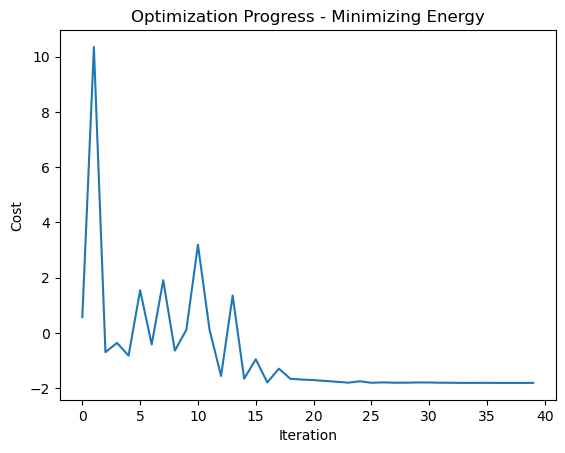

In [57]:
obj_fn_costs_iter = []
parameter_values_iter = []

simulator = AerSimulator(method="statevector", seed_simulator=42)
Aer_transpiled_ckt = transpile(circuit, simulator)

estimator = Estimator(mode=simulator, options={'default_shots': None})
estimator.options.default_shots = 1024*16

param_values_init = [0.77254496, 1.24810316] # [553/L, 1.2481] # [10/L, 10/L]
param_values_init = [2.30713335, 0.9512575 ] # [.002, .01] # [553/L, 1.2481] # [10/L, 10/L]
param_values_init = init_param_values

result = minimize(
        Average_Energy,
        param_values_init,
        args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-6,
        #options={'rhobeg': .0001},
)

optimal_parameters = result.x
optimal_energy = result.fun

print("Optimal parameters:", result.x)
print("Minimum energy:", result.fun)

plt.plot(obj_fn_costs_iter)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Optimization Progress - Minimizing Energy")
plt.show()

## Results


### Generate Sampler output of the circuit assigned with best parameters


In [58]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)
bound_Aer_transpiled_ckt.measure_all()

#display(bound_Aer_transpiled_ckt.draw("mpl"))

sampler = Sampler(mode=simulator)
sampler.options.default_shots = 1024#*16
result = sampler.run([bound_Aer_transpiled_ckt]).result()
#print("result:", result)

#print(result[0].data.meas.get_counts())

#print(result[0].data.keys(), result[0].data.values(), result[0].data.ndim, result[0].data.shape, result[0].data.size)

'''
bit_strings, frequencies = zip(*sorted(zip(result[0].data.meas.get_counts().keys(), list(result[0].data.meas.get_counts().values()))))
Probabilites = [frequencies[i]/sum(frequencies) for i in range(len(frequencies))]
plt.bar(bit_strings, Probabilites)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Probability')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()

'''
#plot_histogram(result[0].data.meas.get_counts(), title="Measurement results with optimal parameters with #layers = " + str(p_reps))


"\nbit_strings, frequencies = zip(*sorted(zip(result[0].data.meas.get_counts().keys(), list(result[0].data.meas.get_counts().values()))))\nProbabilites = [frequencies[i]/sum(frequencies) for i in range(len(frequencies))]\nplt.bar(bit_strings, Probabilites)\nplt.xlabel('Partition (binary representation)')\nplt.ylabel('Probability')\nplt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))\nplt.xticks(rotation=90)\nplt.show()\n\n"

In [59]:
'''
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)

results_StateVector = simulator.run(bound_Aer_transpiled_ckt).result()
counts = results_StateVector.get_counts()
plot_histogram(counts, title="State Vector without measurement")
'''

'\nbound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)\n\nresults_StateVector = simulator.run(bound_Aer_transpiled_ckt).result()\ncounts = results_StateVector.get_counts()\nplot_histogram(counts, title="State Vector without measurement")\n'

### Optimal Scheduling


In [60]:
frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))
'''
plt.bar(bit_strings, frequencies)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Frequency')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()
'''


"\nplt.bar(bit_strings, frequencies)\nplt.xlabel('Partition (binary representation)')\nplt.ylabel('Frequency')\nplt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))\nplt.xticks(rotation=90)\nplt.show()\n"


### Visualization

In [61]:
def solution_at_sampler_matched_idx(bit_strings, w, min_bitstring):

    bit_strings_output = []

    for ir in range(len(bit_strings)):
        bit_strings_output.append([int(bit_strings[ir][i]) for i in range(len(bit_strings[0]))])
        bit_strings_output[ir].reverse()
        matched_idx = ir
        for i in range(len(bit_strings_output[ir])):
            if bit_strings_output[ir][i] != min_bitstring[i]:
                matched_idx = None
                break
        if matched_idx is not None:
            break

    #bit_strings_output = [int(bit_strings[ir][i]) for i in range(len(bit_strings[0]))]
    #bit_strings_output = np.flip(bit_strings_output)

    print('w:\n',w)
    print('c:\n',min_bitstring[:M*N].reshape(M, N))
    print('q:\n',np.array(bit_strings_output[0][:M*N]).reshape(M, N))
    print(f"\n (Solution at sampler freq matched idx) idx |  #samples    | 2**(M*N) \n", '-'*70 )
    print(' '*35, f"   {matched_idx}     {len(bit_strings)}       {2**((M*N))}")


no_of_samples_xzy = 1000

# reverse bitstring from sampler
bit_strings_ = []
for i in range(len(bit_strings)):
    bit_strings_.append(bit_strings[i][::-1])
#bit_strings = bit_strings_
bit_strings_MN = []
for i in range(len(bit_strings_)):
    bit_strings_MN.append(bit_strings_[i][:M*N])
    if i > no_of_samples_xzy:
        break

bit_strings_MN = list((bit_strings_MN))
solution_at_sampler_matched_idx(bit_strings_MN, w, x_brute_force_QUBO_classical.reshape(-1,1))


NameError: name 'x_brute_force_QUBO_classical' is not defined

## End-to-end codeflow

### Code

In [ ]:
binding_dict

{ParameterVectorElement(β[0]): 0.3490658503988659,
 ParameterVectorElement(γ[0]): 0.6283185307179586}

In [ ]:
ckt = Aer_transpiled_ckt
param = ckt.parameters
print(param)
print(param[0], param[2])
dict_player_params = {}
for i in range(0, len(param), p_i):
    dict_player_params[param[i]] = 8
print(dict_player_params)
ckt = ckt.assign_parameters(dict_player_params)
Aer_transpiled_ckt.parameters, ckt.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])
β[0] γ[0]
{ParameterVectorElement(β[0]): 8, ParameterVectorElement(γ[0]): 8}


(ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])]),
 ParameterView([ParameterVectorElement(β[1]), ParameterVectorElement(γ[1])]))

In [ ]:
obj_fn_costs_iter = []
parameter_values_iter = []

N=3
M=2
K = int(np.ceil(np.log2(N)))
p_reps = 2  # incrase p
no_of_samples_xzy = 1000


init_param_values = inititialize_parameters(p_reps)

a_b_c_list = [(1, 1, 1), (1, 1, 10), (1, 1, 100), (1, 10, 1), (1, 10, 10), (1, 10, 100), (1, 100, 1), (1, 100, 10), (1, 100, 100),
            (10, 1, 1), (10, 1, 10), (10, 1, 100), (10, 10, 1), (10, 10, 10), (10, 10, 100), (10, 100, 1), (10, 100, 10), (10, 100, 100),
            (100, 1, 1), (100, 1, 10), (100, 1, 100), (100, 10, 1), (100, 10, 10), (100, 10, 100), (100, 100, 1), (100, 100, 10), (100, 100, 100)]

w = generate_weight_matrix(M, N)  #w = np.array([[37, 41, 31, 26, 79], [39, 50,  1, 46, 81]])
w_col = w.reshape(-1, 1)


if M*N <= 20:
    Time_brute_force_min_max_wx, x_brute_force_min_max_wx = brute_force_min_max_wx(w, M, N)

print('w:\n', w)
print('x_brute_force_min_max_wx:\n', x_brute_force_min_max_wx.reshape(M,N))


n_qubits = M*N + M*K + K
a_b_c_list = [(1, int(np.sqrt(n_qubits)), n_qubits)]

a_b_c_cnt = 0

#for a,b,c in [(10, 10, 1)]:
for a,b,c in a_b_c_list:
#for n_train in range(3):


    '''
    a= 10
    b= 10
    c= 3

    a = 100*10**(-n_train+1)
    b = 1
    c = 10**(n_train-1)
    '''
    
    Q, C = QUBO_Q_C(w, a,b,c)

    print('max abs(Q), max abs(C):', np.max(np.abs(Q)), np.max(np.abs(C)))

    max_Q = np.max(np.abs(Q))
    Q = Q/max_Q
    C = C/max_Q



    if M*N+M*K+K <= 20:
        Time_brute_force_QUBO_classical, x_brute_force_QUBO_classical = brute_force_QUBO_classical(Q, C, w, M, N, K)


    #print('x_brute_force_QUBO_classical:\n', x_brute_force_QUBO_classical.reshape(M,N))

    
    if 1: #Time_brute_force_QUBO_classical > Time_brute_force_min_max_wx:
        print(f"Skipping a={a}, b={b}, c={c} since Time_brute_force_QUBO_classical {Time_brute_force_QUBO_classical} > Time_brute_force_min_max_wx {Time_brute_force_min_max_wx}")
        #continue
    else:
        print('-'*50, '\n',f"Lagrangians a={a}, b={b}, c={c}", '\n', '-'*50)


    pauli_list = classical_qubo_to_hamiltonian(Q/2, C)
    Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=M*N+M*K+K)

    Cost_hamiltonian = Cost_hamiltonian/np.max(np.abs(Cost_hamiltonian.coeffs))

    min_par_values.param_values = []

    for p_i in range(1, p_reps+1):
        print(f"\n\np = {p_i} \n\n")

        init_param_values = min_par_values.param_values.copy()
        min_par_values.param_values = []

        circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_i)

        obj_fn_costs_iter = []
        parameter_values_iter = []
        costFunction_abs_iter = []

        simulator = AerSimulator(method="statevector", seed_simulator=42)
        Aer_transpiled_ckt = transpile(circuit, simulator)

        #Aer_transpiled_ckt.save_statevector()


        if p_i == 1:
            rhobeg_value = 1
        else:
            rhobeg_value = 0.01

        estimator = Estimator(mode=simulator)
        estimator.options.default_shots = None # 1024

        options = EstimatorOptions(
        seed_estimator=42,
        simulator={"seed_simulator": 42},
        default_shots = None
        )

        estimator = Estimator(mode=simulator, options=options)
        




        if p_i==1:
            par1_values = np.arange(0, 1, .125)
            par2_values = np.arange(0, 1, .125)
        else:
            par1_values = [0]#[init_param_values[0]]
            par2_values = [0]#[init_param_values[1]]

        terminate = 0

        for par1 in par1_values:
            for par2 in par2_values:

                #init_param_values = (par1, par2)
                #init_param_values = [-0.38980855, 1.62472997, par1, par2]
                
                param_values_init = init_param_values.copy()

                param_values_init.append(par1)
                param_values_init.append(par2)


                #param_values_init = [-0.38980855, 1.62472997]

                print('param_values_init:', param_values_init)


                result = minimize(
                        Average_Energy,
                        param_values_init,
                        args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
                        method="COBYLA",
                        tol=1e-3,
                        options={'rhobeg': rhobeg_value}
                )

                optimal_parameters = result.x

                print(f"Optimal parameters for a={a}, b={b}, c={c}: {result.x}")
                
                bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)
                bound_Aer_transpiled_ckt.measure_all()

                sampler = Sampler(mode=simulator)
                sampler.options.default_shots = 1024#*16

                for n_sampler in range(1):

                    result = sampler.run([bound_Aer_transpiled_ckt]).result()

                    frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))

                    #-----------------------------------------------------------------------------------------------------------------------------------------------------
                    
                    # reverse bitstring from sampler
                    bit_strings_ = []
                    for i in range(len(bit_strings)):
                        bit_strings_.append(bit_strings[i][::-1])
                    bit_strings = bit_strings_

                    bit_strings_MN = []
                    for i in range(len(bit_strings)):
                        bit_strings_MN.append(bit_strings[i][:M*N])
                        if i > no_of_samples_xzy:
                            break

                    bit_strings_MN = list(bit_strings_MN)
                    n_samples_violating_equal_to_1_constraint = 0
                    n_samples_not_having_N_1s = 0
                    cnt = 0
                    min_maxTime = 1000000
                    min_reshaped_x = None
                    min_idx = 1111111111
                    for i in range(len(bit_strings_MN)):
                        list_x = [int(bit_strings_MN[i][j]) for j in range(len(bit_strings_MN[i]))]
                        #print(i, cnt, len(bit_strings_MN))
                        if sum(list_x) == N:
                            reshaped_x = np.array(list_x).reshape(M,N)
                            bool_skip_maxTime = 0
                            for l in range(N):
                                if np.sum(reshaped_x[:,l])!=1:
                                    bool_skip_maxTime = 1
                                    break
                            if bool_skip_maxTime:
                                n_samples_violating_equal_to_1_constraint += 1
                                continue
                            alloted_times = reshaped_x * w
                            max_time = 0
                            for j in range(M):
                                max_time = max(max_time, np.sum(alloted_times[j,:]))
                            #print(i, max_time)
                            if min_maxTime > max_time:
                                min_maxTime = max_time
                                min_reshaped_x = reshaped_x
                                min_idx = cnt
                            if cnt == 0:
                                min_maxTime_1st = max_time
                                min_reshaped_x_1st = reshaped_x
                            cnt += 1
                        else:
                            n_samples_not_having_N_1s += 1



                    if a_b_c_cnt == 0:
                        if M*N <= 20:
                            print('    Time_brute_force_min_max_wx ', Time_brute_force_min_max_wx)
                            print('    a     b     c   QUBO  1st   min  f_idx #samples of  of  of 2**MN ')
                    print(f'{a:5d} {b:5d} {c:5d} {Time_brute_force_QUBO_classical:5d} {min_maxTime_1st:5d} {min_maxTime:5d} {min_idx:4d} {cnt:5d} {len(bit_strings_MN):5d} {no_of_samples_xzy:5d} {2**(M*N):5d}')




                    '''
                    print(f'#constrain_satisfied #unique #samples_chosen of #2**(M*N)')
                    print(f'     #samples {cnt}  of  {len(bit_strings_MN)}  of     {no_of_samples_xzy}     of     {2**(M*N)}')
                    print(f'#samples violating equality constraint(B)  {n_samples_violating_equal_to_1_constraint}', 
                        '  =>Atleast 1 task assigned to >1 workers and atleast 1 task assigned to None')
                    print(f'  n_samples_not_having_N_1s {n_samples_not_having_N_1s}')
                    print('w\n', w)
                    print('\n Predicted 1st min_reshaped_x\n', min_reshaped_x_1st, 'Predicted 1st min_maxTime ', min_maxTime_1st)
                    print('\n Predicted min_reshaped_x\n', min_reshaped_x, 'Predicted min_maxTime ', min_maxTime, f'( at filtered idx {min_idx} )')
                    if M*N <= 20:
                        print('\n x_brute_force_min_max_wx \n', x_brute_force_min_max_wx, '    Time_brute_force_min_max_wx ', Time_brute_force_min_max_wx)
                    if M*N+M*K+K <= 20:
                        print('\n x_brute_force_QUBO_classical \n', x_brute_force_QUBO_classical, '    Time_brute_force_QUBO_classical ', Time_brute_force_QUBO_classical)
                    '''   

                    #print(' '*50, list(frequencies)[:4],list(bit_strings_MN)[:4], sum(frequencies))

                    #print('w: \n',w)
                    #print('min_reshaped_x_1st: \n', min_reshaped_x_1st, '     min_maxTime_1st: ', min_maxTime_1st)

                    if min_par_values.min_maxTime_1st > min_maxTime_1st or len(min_par_values.param_values) == 0: # p_i == 1:
                        min_par_values.assign(a, b, c, list(optimal_parameters), min_maxTime_1st)

                    if Time_brute_force_QUBO_classical == min_maxTime_1st:
                        terminate = 1
                        break


                    #plt.plot(frequencies)

                if terminate:
                    break # parameter loop
            if terminate:
                break # parameter loop


        min_par_values.display()

    #if terminate:
    break # Lagrangian loop


'''
plt.close()
plt.plot(costFunction_abs_iter)
plt.plot(obj_fn_costs_iter)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Optimization Progress - Minimizing Energy")
plt.show()
'''


w:
 [[544 139 508]
 [685 125 714]]
x_brute_force_min_max_wx:
 [[0 1 1]
 [1 0 0]]
max abs(Q), max abs(C): 4.0 28.0
Skipping a=1, b=3, c=12 since Time_brute_force_QUBO_classical 685 > Time_brute_force_min_max_wx 685


p = 1 


param_values_init: [np.float64(0.0), np.float64(0.0)]
Optimal parameters for a=1, b=3, c=12: [1. 0.]
    Time_brute_force_min_max_wx  685
    a     b     c   QUBO  1st   min  f_idx #samples of  of  of 2**MN 
    1     3    12   685  1399   685    1   107   889  1000    64
param_values_init: [np.float64(0.0), np.float64(0.125)]
Optimal parameters for a=1, b=3, c=12: [-0.86553213  0.31197653]
    Time_brute_force_min_max_wx  685
    a     b     c   QUBO  1st   min  f_idx #samples of  of  of 2**MN 
    1     3    12   685   685   685    0    83   695  1000    64
a: 1, b: 3, c: 12, param_values: [np.float64(-0.8655321271970582), np.float64(0.31197652832719763)], min_maxTime_1st: 685


p = 2 


param_values_init: [np.float64(-0.8655321271970582), np.float64(0.3119765283

'\nplt.close()\nplt.plot(costFunction_abs_iter)\nplt.plot(obj_fn_costs_iter)\nplt.xlabel("Iteration")\nplt.ylabel("Cost")\nplt.title("Optimization Progress - Minimizing Energy")\nplt.show()\n'

### Freeze previous layers

w:
 [[318  40  33 232]
 [375 761  16 461]
 [248 987 421 871]]
x_brute_force_min_max_wx:
 [[0 1 0 1]
 [0 0 1 0]
 [1 0 0 0]]
max abs(Q), max abs(C): 4.0 44.0
Skipping a=1, b=4, c=20 since Time_brute_force_QUBO_classical 272 > Time_brute_force_min_max_wx 272


p = 1 


param_values_init: (np.float64(0.0), np.float64(0.0))


c:\Users\kcrav\miniconda3\envs\myenv\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'seed_estimator': 42} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


Optimal parameters for a=1, b=4, c=20: [1. 0.]
    Time_brute_force_min_max_wx  272
    a     b     c   QUBO  1st   min  f_idx #samples of  of  of 2**MN 
    1     4    20   272  2279   391   11    17  1002  1000  4096
param_values_init: (np.float64(0.0), np.float64(0.125))
Optimal parameters for a=1, b=4, c=20: [-0.73199717  0.89162893]
    Time_brute_force_min_max_wx  272
    a     b     c   QUBO  1st   min  f_idx #samples of  of  of 2**MN 
    1     4    20   272  1408   305   11    21  1002  1000  4096
param_values_init: (np.float64(0.0), np.float64(0.25))
Optimal parameters for a=1, b=4, c=20: [-0.70244724  0.86251716]
    Time_brute_force_min_max_wx  272
    a     b     c   QUBO  1st   min  f_idx #samples of  of  of 2**MN 
    1     4    20   272   461   272   12    16  1002  1000  4096
param_values_init: (np.float64(0.0), np.float64(0.375))
Optimal parameters for a=1, b=4, c=20: [-0.73914007  0.95269292]
    Time_brute_force_min_max_wx  272
    a     b     c   QUBO  1st   min  f

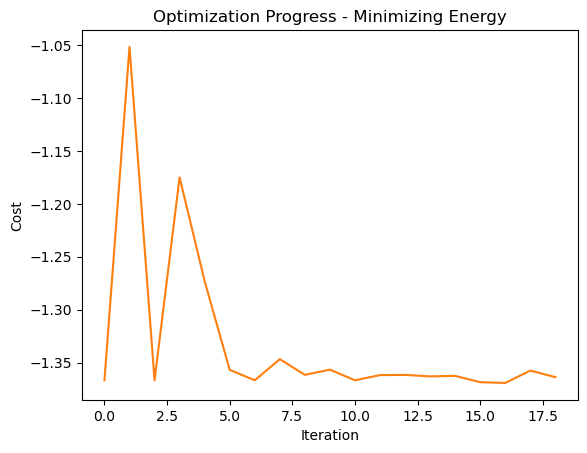

In [77]:
obj_fn_costs_iter = []
parameter_values_iter = []

N=4
M=3
K = int(np.ceil(np.log2(N)))
p_reps = 2  # incrase p
no_of_samples_xzy = 1000


init_param_values = inititialize_parameters(p_reps)

a_b_c_list = [(1, 1, 1), (1, 1, 10), (1, 1, 100), (1, 10, 1), (1, 10, 10), (1, 10, 100), (1, 100, 1), (1, 100, 10), (1, 100, 100),
            (10, 1, 1), (10, 1, 10), (10, 1, 100), (10, 10, 1), (10, 10, 10), (10, 10, 100), (10, 100, 1), (10, 100, 10), (10, 100, 100),
            (100, 1, 1), (100, 1, 10), (100, 1, 100), (100, 10, 1), (100, 10, 10), (100, 10, 100), (100, 100, 1), (100, 100, 10), (100, 100, 100)]

#w = generate_weight_matrix(M, N)  #w = np.array([[37, 41, 31, 26, 79], [39, 50,  1, 46, 81]])
w_col = w.reshape(-1, 1)


if M*N <= 20:
    Time_brute_force_min_max_wx, x_brute_force_min_max_wx = brute_force_min_max_wx(w, M, N)

print('w:\n', w)
print('x_brute_force_min_max_wx:\n', x_brute_force_min_max_wx.reshape(M,N))


n_qubits = M*N + M*K + K
a_b_c_list = [(1, int(np.sqrt(n_qubits)), n_qubits)]

a_b_c_cnt = 0

#for a,b,c in [(10, 10, 1)]:
for a,b,c in a_b_c_list:
#for n_train in range(3):


    '''
    a= 10
    b= 10
    c= 3

    a = 100*10**(-n_train+1)
    b = 1
    c = 10**(n_train-1)
    '''
    
    Q, C = QUBO_Q_C(w, a,b,c)

    print('max abs(Q), max abs(C):', np.max(np.abs(Q)), np.max(np.abs(C)))

    max_Q = np.max(np.abs(Q))
    Q = Q/max_Q
    C = C/max_Q



    if M*N+M*K+K <= 20:
        Time_brute_force_QUBO_classical, x_brute_force_QUBO_classical = brute_force_QUBO_classical(Q, C, w, M, N, K)


    #print('x_brute_force_QUBO_classical:\n', x_brute_force_QUBO_classical.reshape(M,N))

    
    if 1: #Time_brute_force_QUBO_classical > Time_brute_force_min_max_wx:
        print(f"Skipping a={a}, b={b}, c={c} since Time_brute_force_QUBO_classical {Time_brute_force_QUBO_classical} > Time_brute_force_min_max_wx {Time_brute_force_min_max_wx}")
        #continue
    else:
        print('-'*50, '\n',f"Lagrangians a={a}, b={b}, c={c}", '\n', '-'*50)


    pauli_list = classical_qubo_to_hamiltonian(Q/2, C)
    Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=M*N+M*K+K)

    Cost_hamiltonian = Cost_hamiltonian/np.max(np.abs(Cost_hamiltonian.coeffs))


    min_par_values.param_values = []

    dict_params = {}

    for p_i in range(1, p_reps+1):
        print(f"\n\np = {p_i} \n\n")

        init_param_values = min_par_values.param_values.copy()
        min_par_values.param_values = []

        circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_i)

        obj_fn_costs_iter = []
        parameter_values_iter = []
        costFunction_abs_iter = []

        #if p_i == 2:
        #    print(Aer_transpiled_ckt) #----------------------------------------------

        simulator = AerSimulator(method="statevector", seed_simulator=42)
        Aer_transpiled_ckt = transpile(circuit, simulator)

        #Aer_transpiled_ckt.save_statevector()

            

        estimator = Estimator(mode=simulator)
        estimator.options.default_shots = None # 1024

        options = EstimatorOptions(
        seed_estimator=42,
        simulator={"seed_simulator": 42},
        default_shots = None
        )

        estimator = Estimator(mode=simulator, options=options)
        


        if p_i==1:
            par1_values = np.arange(0, 1, .125)
            par2_values = np.arange(0, 1, .125)
            rhobeg_value = 1
        else:
            par1_values = [0]#[init_param_values[0]]
            par2_values = [0]#[init_param_values[1]]
            rhobeg_value = 0.3

            strKeys_dict_params = {param.name: value for param, value in dict_params.items()}
            binding = {
                param: strKeys_dict_params[param.name]
                for param in Aer_transpiled_ckt.parameters
                if param.name in strKeys_dict_params
            }
            Aer_transpiled_ckt.assign_parameters(binding, inplace=True)
            #Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(dict_params)
            


        terminate = 0

        for par1 in par1_values:
            for par2 in par2_values:

                init_param_values = (par1, par2)
                #init_param_values = [-0.38980855, 1.62472997, par1, par2]
                
                param_values_init = init_param_values

                #param_values_init.append(par1)
                #param_values_init.append(par2)


                #param_values_init = [-0.38980855, 1.62472997]

                print('param_values_init:', param_values_init)


                result = minimize(
                        Average_Energy,
                        param_values_init,
                        args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
                        method="COBYLA",
                        tol=1e-3,
                        options={'rhobeg': rhobeg_value}
                )

                optimal_parameters = result.x

                print(f"Optimal parameters for a={a}, b={b}, c={c}: {result.x}")
                
                #---------------- check for identity -----------------------------------------------------------
                #if p_i == 2:
                #    optimal_parameters = [0, 0] 
                #-------------------------------------------------------------------------------------------------

                bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)

                #-------------------------------------------------------------------------------------------------
                '''
                op = qi.Operator(bound_Aer_transpiled_ckt)
                input = np.zeros(2**(M*N+M*K+K))
                input[0] = 1
                psi_gama_beta = op.data@input
                if p_i == 2:
                    inner_prod = np.vdot(psi_gama_beta, prev_psi_gama_beta)
                    print('<psi_p1|psi_p1p2>:', inner_prod)
                prev_psi_gama_beta = psi_gama_beta
                '''
                #-------------------------------------------------------------------------------------------------

                bound_Aer_transpiled_ckt.measure_all()


                sampler = Sampler(mode=simulator)
                sampler.options.default_shots = 1024#*16

                for n_sampler in range(1):

                    result = sampler.run([bound_Aer_transpiled_ckt]).result()

                    frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))

                    #-----------------------------------------------------------------------------------------------------------------------------------------------------
                    
                    # reverse bitstring from sampler
                    bit_strings_ = []
                    for i in range(len(bit_strings)):
                        bit_strings_.append(bit_strings[i][::-1])
                    bit_strings = bit_strings_

                    bit_strings_MN = []
                    for i in range(len(bit_strings)):
                        bit_strings_MN.append(bit_strings[i][:M*N])
                        if i > no_of_samples_xzy:
                            break

                    bit_strings_MN = list(bit_strings_MN)
                    n_samples_violating_equal_to_1_constraint = 0
                    n_samples_not_having_N_1s = 0
                    cnt = 0
                    min_maxTime = 1000000
                    min_reshaped_x = None
                    min_idx = 1111111111
                    for i in range(len(bit_strings_MN)):
                        list_x = [int(bit_strings_MN[i][j]) for j in range(len(bit_strings_MN[i]))]
                        #print(i, cnt, len(bit_strings_MN))
                        if sum(list_x) == N:
                            reshaped_x = np.array(list_x).reshape(M,N)
                            bool_skip_maxTime = 0
                            for l in range(N):
                                if np.sum(reshaped_x[:,l])!=1:
                                    bool_skip_maxTime = 1
                                    break
                            if bool_skip_maxTime:
                                n_samples_violating_equal_to_1_constraint += 1
                                continue
                            alloted_times = reshaped_x * w
                            max_time = 0
                            for j in range(M):
                                max_time = max(max_time, np.sum(alloted_times[j,:]))
                            #print(i, max_time)
                            if min_maxTime > max_time:
                                min_maxTime = max_time
                                min_reshaped_x = reshaped_x
                                min_idx = cnt
                            if cnt == 0:
                                min_maxTime_1st = max_time
                                min_reshaped_x_1st = reshaped_x
                            cnt += 1
                        else:
                            n_samples_not_having_N_1s += 1



                    if a_b_c_cnt == 0:
                        if M*N <= 20:
                            print('    Time_brute_force_min_max_wx ', Time_brute_force_min_max_wx)
                            print('    a     b     c   QUBO  1st   min  f_idx #samples of  of  of 2**MN ')
                    print(f'{a:5d} {b:5d} {c:5d} {Time_brute_force_QUBO_classical:5d} {min_maxTime_1st:5d} {min_maxTime:5d} {min_idx:4d} {cnt:5d} {len(bit_strings_MN):5d} {no_of_samples_xzy:5d} {2**(M*N):5d}')




                    '''
                    print(f'#constrain_satisfied #unique #samples_chosen of #2**(M*N)')
                    print(f'     #samples {cnt}  of  {len(bit_strings_MN)}  of     {no_of_samples_xzy}     of     {2**(M*N)}')
                    print(f'#samples violating equality constraint(B)  {n_samples_violating_equal_to_1_constraint}', 
                        '  =>Atleast 1 task assigned to >1 workers and atleast 1 task assigned to None')
                    print(f'  n_samples_not_having_N_1s {n_samples_not_having_N_1s}')
                    print('w\n', w)
                    print('\n Predicted 1st min_reshaped_x\n', min_reshaped_x_1st, 'Predicted 1st min_maxTime ', min_maxTime_1st)
                    print('\n Predicted min_reshaped_x\n', min_reshaped_x, 'Predicted min_maxTime ', min_maxTime, f'( at filtered idx {min_idx} )')
                    if M*N <= 20:
                        print('\n x_brute_force_min_max_wx \n', x_brute_force_min_max_wx, '    Time_brute_force_min_max_wx ', Time_brute_force_min_max_wx)
                    if M*N+M*K+K <= 20:
                        print('\n x_brute_force_QUBO_classical \n', x_brute_force_QUBO_classical, '    Time_brute_force_QUBO_classical ', Time_brute_force_QUBO_classical)
                    '''   

                    #print(' '*50, list(frequencies)[:4],list(bit_strings_MN)[:4], sum(frequencies))

                    #print('w: \n',w)
                    #print('min_reshaped_x_1st: \n', min_reshaped_x_1st, '     min_maxTime_1st: ', min_maxTime_1st)

                    if min_par_values.min_maxTime_1st > min_maxTime_1st or len(min_par_values.param_values) == 0: # p_i == 1:
                        min_par_values.assign(a, b, c, list(optimal_parameters), min_maxTime_1st)
                        params = Aer_transpiled_ckt.parameters
                        dict_params[params[0]] = optimal_parameters[0]
                        dict_params[params[1]] = optimal_parameters[1]

                    if Time_brute_force_QUBO_classical == min_maxTime_1st:
                        terminate = 1
                        break


                    #plt.plot(frequencies)

                if terminate:
                    break # parameter loop
            if terminate:
                break # parameter loop


        min_par_values.display()

    #if terminate:
    break # Lagrangian loop



plt.close()
plt.plot(costFunction_abs_iter)
plt.plot(obj_fn_costs_iter)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Optimization Progress - Minimizing Energy")
plt.show()



In [79]:
min_reshaped_x_1st

array([[0, 0, 0, 0],
       [0, 0, 1, 1],
       [1, 1, 0, 0]])

In [78]:
parameter_values_iter, obj_fn_costs_iter

([[np.float64(0.0), np.float64(0.0)],
  [np.float64(0.3), np.float64(0.0)],
  [np.float64(0.0), np.float64(0.3)],
  [np.float64(-0.3), np.float64(0.0)],
  [np.float64(0.15000000000000002), np.float64(0.0)],
  [np.float64(-0.075), np.float64(0.0)],
  [np.float64(0.0), np.float64(0.015)],
  [np.float64(0.030000000000000002), np.float64(0.0)],
  [np.float64(-0.030000000000000002), np.float64(0.0)],
  [np.float64(0.014999999999999998), np.float64(0.0)],
  [np.float64(0.0), np.float64(0.0027386127875258306)],
  [np.float64(-0.005477225575051662), np.float64(0.0)],
  [np.float64(0.005477225575051662), np.float64(0.0)],
  [np.float64(-0.0027386127875258306), np.float64(0.0)],
  [np.float64(0.0005), np.float64(0.0)],
  [np.float64(-0.001), np.float64(0.0)],
  [np.float64(-0.002), np.float64(0.0)],
  [np.float64(-0.002855120805733105), np.float64(-0.0005184287873974255)],
  [np.float64(-0.00202853787865844), np.float64(0.0009995927117989988)]],
 [array(-1.36678221),
  array(-1.05173611),
  arra

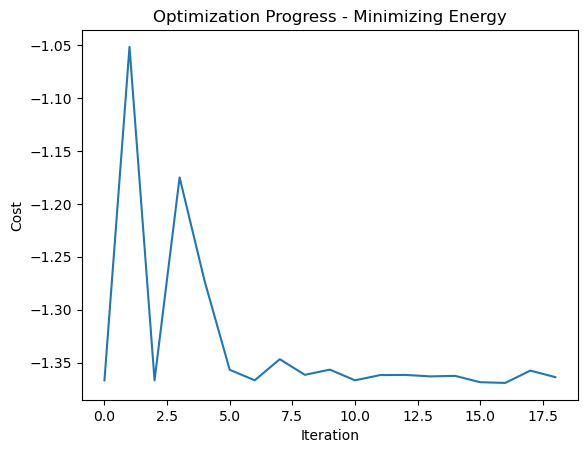

In [76]:
plt.plot(obj_fn_costs_iter)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Optimization Progress - Minimizing Energy")
plt.show()

In [ ]:
for param in dict_params.keys():
    print(param)
Aer_transpiled_ckt.parameters

β[0]
γ[0]
β[1]
γ[1]


ParameterView([ParameterVectorElement(β[1]), ParameterVectorElement(γ[1])])

In [ ]:
diff = op.data - op.data.T
np.sum(diff), np.sum(op.data)

(np.complex128(-1.4210854715202004e-14+2.1316282072803006e-14j),
 np.complex128(-63.461181303924064-8.28724728184637j))

In [ ]:
inv = np.linalg.inv(op.data)

In [ ]:
np.sum(inv)

np.complex128(-63.461181303924015+8.287247281846255j)

In [ ]:
diff = inv-op.data
np.sum(diff)

np.complex128(16.574494563692603j)

In [ ]:
I = inv@op.data
np.sum(I)

np.complex128(4095.9999999999995+2.7963742793954184e-13j)

### P=1 grid search then COBYLA

In [ ]:
obj_fn_costs_iter = []
parameter_values_iter = []

N=4
M=3
K = int(np.ceil(np.log2(N)))
p_reps = 2  # incrase p
no_of_samples_xzy = 1000


init_param_values = inititialize_parameters(p_reps)

a_b_c_list = [(1, 1, 1), (1, 1, 10), (1, 1, 100), (1, 10, 1), (1, 10, 10), (1, 10, 100), (1, 100, 1), (1, 100, 10), (1, 100, 100),
            (10, 1, 1), (10, 1, 10), (10, 1, 100), (10, 10, 1), (10, 10, 10), (10, 10, 100), (10, 100, 1), (10, 100, 10), (10, 100, 100),
            (100, 1, 1), (100, 1, 10), (100, 1, 100), (100, 10, 1), (100, 10, 10), (100, 10, 100), (100, 100, 1), (100, 100, 10), (100, 100, 100)]

w = generate_weight_matrix(M, N)  #w = np.array([[37, 41, 31, 26, 79], [39, 50,  1, 46, 81]])
w_col = w.reshape(-1, 1)


if M*N <= 20:
    Time_brute_force_min_max_wx, x_brute_force_min_max_wx = brute_force_min_max_wx(w, M, N)

print('w:\n', w)
print('x_brute_force_min_max_wx:\n', x_brute_force_min_max_wx.reshape(M,N))


n_qubits = M*N + M*K + K
a_b_c_list = [(1, int(np.sqrt(n_qubits)), n_qubits)]

a_b_c_cnt = 0

#for a,b,c in [(10, 10, 1)]:
for a,b,c in a_b_c_list:
#for n_train in range(3):
    
    Q, C = QUBO_Q_C(w, a,b,c)

    print('max abs(Q), max abs(C):', np.max(np.abs(Q)), np.max(np.abs(C)))

    max_Q = np.max(np.abs(Q))
    Q = Q/max_Q
    C = C/max_Q


    if M*N+M*K+K <= 20:
        Time_brute_force_QUBO_classical, x_brute_force_QUBO_classical = brute_force_QUBO_classical(Q, C, w, M, N, K)

    if 1: #Time_brute_force_QUBO_classical > Time_brute_force_min_max_wx:
        print(f"Skipping a={a}, b={b}, c={c} since Time_brute_force_QUBO_classical {Time_brute_force_QUBO_classical} > Time_brute_force_min_max_wx {Time_brute_force_min_max_wx}")
        #continue
    else:
        print('-'*50, '\n',f"Lagrangians a={a}, b={b}, c={c}", '\n', '-'*50)


    pauli_list = classical_qubo_to_hamiltonian(Q/2, C)
    Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=M*N+M*K+K)

    Cost_hamiltonian = Cost_hamiltonian/np.max(np.abs(Cost_hamiltonian.coeffs))

    min_par_values.param_values = []

    for p_i in range(1, p_reps+1):
        print(f"\n\np = {p_i} \n\n")

        init_param_values = min_par_values.param_values.copy()
        min_par_values.param_values = []

        circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_i)

        obj_fn_costs_iter = []
        parameter_values_iter = []
        costFunction_abs_iter = []

        simulator = AerSimulator(method="statevector", seed_simulator=42)
        Aer_transpiled_ckt = transpile(circuit, simulator)

        #Aer_transpiled_ckt.save_statevector()

        estimator = Estimator(mode=simulator)
        estimator.options.default_shots = None # 1024

        options = EstimatorOptions(
        seed_estimator=42,
        simulator={"seed_simulator": 42},
        default_shots = None
        )

        estimator = Estimator(mode=simulator, options=options)
        


        if p_i==1:

            grid_steps = 25
            k_mins = 10

            Avg_E_grid = np.zeros((grid_steps, grid_steps))
            param_grid = np.zeros((grid_steps, grid_steps, 2))
            for i, gama_i in enumerate(np.arange(0, np.pi/2, np.pi/(2*grid_steps))):
                for j, beta_j in enumerate(np.arange(0, np.pi, np.pi/grid_steps)):
                    param_values = [gama_i, beta_j]
                    Avg_E = Average_Energy(param_values, Aer_transpiled_ckt, Cost_hamiltonian, estimator)

                    Avg_E_grid[i, j] = Avg_E
                    param_grid[i, j, :] = np.array(param_values)

            fig = plt.figure()
            ax = plt.axes(projection='3d')
            ax.plot_surface(param_grid[:,:,0], param_grid[:,:,1], Avg_E_grid, cmap='viridis')
            np.min((Avg_E_grid)), np.max((Avg_E_grid))

            rows, cols = get_k_min_2D_indices(Avg_E_grid, k=k_mins)


            min_Avg_Energy = 1000000
            min_params = None

            for idx in range(k_mins):

                param_values_init = param_grid[rows[idx], cols[idx], :].copy()
                
                result = minimize(
                        Average_Energy,
                        param_values_init,
                        args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
                        method="COBYLA",
                        tol=1e-3,
                )

                if min_Avg_Energy > result.fun:
                    min_Avg_Energy = result.fun
                    min_params = result.x

                #print(f"Optimal parameters for a={a}, b={b}, c={c}: {result.x}, Energy: {result.fun}")
                #display(result)

        else:
            pass

        bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(min_params)
        bound_Aer_transpiled_ckt.measure_all()

        sampler = Sampler(mode=simulator)
        sampler.options.default_shots = 1024#*16


        for n_sampler in range(1):

            result = sampler.run([bound_Aer_transpiled_ckt]).result()

            frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))

            #-----------------------------------------------------------------------------------------------------------------------------------------------------
            
            # reverse bitstring from sampler
            bit_strings_ = []
            for i in range(len(bit_strings)):
                bit_strings_.append(bit_strings[i][::-1])
            bit_strings = bit_strings_

            bit_strings_MN = []
            for i in range(len(bit_strings)):
                bit_strings_MN.append(bit_strings[i][:M*N])
                if i > no_of_samples_xzy:
                    break

            bit_strings_MN = list(bit_strings_MN)
            n_samples_violating_equal_to_1_constraint = 0
            n_samples_not_having_N_1s = 0
            cnt = 0
            min_maxTime = 1000000
            min_reshaped_x = None
            min_idx = 1111111111
            for i in range(len(bit_strings_MN)):
                list_x = [int(bit_strings_MN[i][j]) for j in range(len(bit_strings_MN[i]))]
                #print(i, cnt, len(bit_strings_MN))
                if sum(list_x) == N:
                    reshaped_x = np.array(list_x).reshape(M,N)
                    bool_skip_maxTime = 0
                    for l in range(N):
                        if np.sum(reshaped_x[:,l])!=1:
                            bool_skip_maxTime = 1
                            break
                    if bool_skip_maxTime:
                        n_samples_violating_equal_to_1_constraint += 1
                        continue
                    alloted_times = reshaped_x * w
                    max_time = 0
                    for j in range(M):
                        max_time = max(max_time, np.sum(alloted_times[j,:]))
                    #print(i, max_time)
                    if min_maxTime > max_time:
                        min_maxTime = max_time
                        min_reshaped_x = reshaped_x
                        min_idx = cnt
                    if cnt == 0:
                        min_maxTime_1st = max_time
                        min_reshaped_x_1st = reshaped_x
                    cnt += 1
                else:
                    n_samples_not_having_N_1s += 1



            if a_b_c_cnt == 0:
                if M*N <= 20:
                    print('    Time_brute_force_min_max_wx ', Time_brute_force_min_max_wx)
                    print('    a     b     c   QUBO  1st   min  f_idx #samples of  of  of 2**MN ')
            print(f'{a:5d} {b:5d} {c:5d} {Time_brute_force_QUBO_classical:5d} {min_maxTime_1st:5d} {min_maxTime:5d} {min_idx:4d} {cnt:5d} {len(bit_strings_MN):5d} {no_of_samples_xzy:5d} {2**(M*N):5d}')


            #print(' '*50, list(frequencies)[:4],list(bit_strings_MN)[:4], sum(frequencies))

            #print('w: \n',w)
            #print('min_reshaped_x_1st: \n', min_reshaped_x_1st, '     min_maxTime_1st: ', min_maxTime_1st)

            if min_par_values.min_maxTime_1st > min_maxTime_1st or len(min_par_values.param_values) == 0: # p_i == 1:
                min_par_values.assign(a, b, c, list(min_params), min_maxTime_1st)



        min_par_values.display()



In [ ]:
min_par_values.display()
min_params

a: 1, b: 4, c: 20, param_values: [], min_maxTime_1st: 868


array([2.67470136, 0.86712475])

(np.float64(-1.350028335924828), np.float64(1.353068056953223))

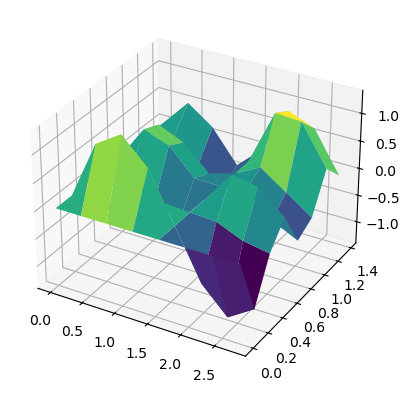

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(param_grid[:,:,0], param_grid[:,:,1], Avg_E_grid, cmap='viridis')
np.min((Avg_E_grid)), np.max((Avg_E_grid))

In [ ]:
rows, cols

(array([6, 7, 5, 3]), array([1, 1, 1, 6]))

In [ ]:
k = 4



rows, cols = get_k_min_2D_indices(Avg_E_grid, k)

for r, c in zip(rows, cols):
    print(f"value={Avg_E_grid[r, c]}, position=({r},{c})")

value=-1.350028335924828, position=(6,1)
value=-1.04410728768237, position=(7,1)
value=-0.8799198155285921, position=(5,1)
value=-0.6568749131029401, position=(3,6)


### misc

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Create a simple circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Get statevector
state = Statevector.from_instruction(qc)

# Display the result
print(state)
state.draw('latex')


Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


<IPython.core.display.Latex object>

In [ ]:
state = Statevector.from_instruction(circuit.assign_parameters(optimal_parameters))

boundCkt =circuit.assign_parameters(init_param_values)

op = qi.Operator(boundCkt)

input = np.zeros(2**(M*N+M*K+K))
input[0] = 1

psi_gama_beta = input.T@op.data 

print(len(state.data), circuit.num_qubits)
print(state)
print(psi_gama_beta)

state.draw('latex')

In [ ]:
circuit.num_qubits

7

In [ ]:
qi.Operator(circuit.assign_parameters(init_param_values))

In [ ]:
def fn_x(init_param_values, circuit, Cost_hamiltonian):

    boundCkt =circuit.assign_parameters(init_param_values)

    op = qi.Operator(boundCkt)

    input = np.zeros(2**(M*N+M*K+K))
    input[0] = 1

    psi_gama_beta = input.T@op.data # @input

    Hc = Cost_hamiltonian.to_matrix()

    cost_complex = psi_gama_beta.T @ Hc @ psi_gama_beta
    #costFunction_abs = np.abs(cost_complex)
    costFunction_abs = cost_complex.real

    costFunction_abs_iter.append(costFunction_abs)

    return costFunction_abs

fn_x(init_param_values, circuit, Cost_hamiltonian)

np.float64(2.4163931424046106)

In [ ]:
result = minimize(
        fn_x,
        init_param_values,
        args=(Aer_transpiled_ckt, Cost_hamiltonian), #, estimator),
        method="COBYLA",
        tol=1e-6,
        #options={'rhobeg': .0001},
)

result

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.7721764852736364
       x: [ 1.844e+00  9.497e-01]
    nfev: 59
   maxcv: 0.0

In [ ]:
init_param_values, circuit.parameters

([0.4487989505128276, 0.18479956785822313],
 ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(γ[0])]))

In [ ]:
op = qi.Operator(circuit.assign_parameters(init_param_values))
op.data.shape, op.data.ndim, op.data.size

c:\Users\kcrav\miniconda3\envs\myenv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\kcrav\miniconda3\envs\myenv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


((128, 128), 2, 16384)

In [ ]:
ckt = circuit.assign_parameters(init_param_values)

qi.Operator(ckt)